# Домашнее задание №1: Online Shoppers Intention

# 1. Загрузка и первичный осмотр данных

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [49]:
df.shape

(12330, 18)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## Описание признаков

| Столбец | Перевод | Описание |
|---|---|---|
| `Administrative` | Административные страницы | Количество посещённых административных страниц |
| `Administrative_Duration` | Время на административных страницах | Общее время, проведённое на административных страницах |
| `Informational` | Информационные страницы | Количество посещённых информационных страниц |
| `Informational_Duration` | Время на информационных страницах | Общее время, проведённое на информационных страницах |
| `ProductRelated` | Страницы товаров | Количество посещённых страниц, связанных с товарами |
| `ProductRelated_Duration` | Время на страницах товаров | Общее время, проведённое на страницах товаров |
| `BounceRates` | Показатель отказов | Доля посещений, во время которых пользователь быстро покинул сайт |
| `ExitRates` | Показатель выхода | Доля выходов со страницы во время сессий |
| `PageValues` | Ценность страницы | Средняя ценность страницы с точки зрения последующей покупки |
| `SpecialDay` | Особый день | Близость даты посещения к празднику или другой специальной дате |
| `Month` | Месяц | Месяц, в котором произошёл визит |
| `OperatingSystems` | Операционная система | Код операционной системы пользователя |
| `Browser` | Браузер | Код браузера пользователя |
| `Region` | Регион | Код региона пользователя |
| `TrafficType` | Тип трафика | Код источника или типа трафика |
| `VisitorType` | Тип посетителя | Новый посетитель, постоянный посетитель или другой тип |
| `Weekend` | Выходной день | Был ли визит совершён в выходной день |
| `Revenue` | Покупка | Целевая переменная: совершил пользователь покупку или нет |

Каждая строка отвечает за одного пользователя и его действия. У нас задача бинарной классификации. Значет логично выбрать столбец типа bool. Поэтому в качестве целевой переменной я решил выбрать revenue. Этот столбец отвечает за то, сделал ли пользователь покупку.

# 2. Гипотезы

1. Технические характеристики браузера, ОС и части источников трафика будут менее важны, чем другие признаки поведения человека в сессии
2. Дисбаланс классов. Уже сразу можно предположить, что пользователи покупают гораздно реже, чем просто посмотрят и уйдут с сайта
3. Вероятность покупки будет зависеть от месяца, то есть в данных будет наблюдаться сезонность 
4. L1-регуляризация позволит сократить число признаков и улучшит качество модели
5. При увеличении глубины дерева качество на обучении будет расти, а качество на тесте после некоторого значения начнёт падать

# 3. EDA

- Количественные признаки: количество страниц и время на них, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`.
- Категориальные признаки: `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`.
- Бинарный признак: `Weekend`.
- Целевая переменная: `Revenue`.

Значения `OperatingSystems`, `Browser`, `Region` и `TrafficType` являются кодами категорий. Их нельзя интерпретировать как обычные числа: например, браузер с кодом `4` не является «больше» браузера с кодом `1`.

In [51]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Пропуски:

In [52]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

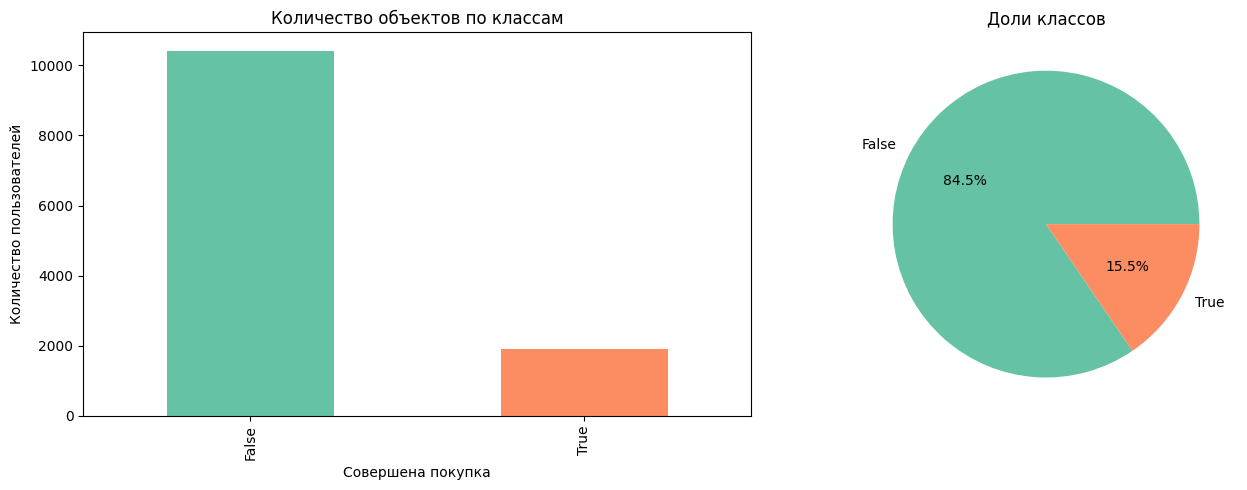

In [53]:
target = 'Revenue'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[target].value_counts().plot.bar(
    ax=axes[0],
    color=sns.color_palette("Set2")
)
axes[0].set_title("Количество объектов по классам")
axes[0].set_xlabel("Совершена покупка")
axes[0].set_ylabel("Количество пользователей")

df[target].value_counts(normalize=True).plot.pie(
    ax=axes[1],
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2")
)
axes[1].set_ylabel("")
axes[1].set_title("Доли классов")
plt.tight_layout()
plt.show()

Сразу видим дизбаланс. Тут поддтвердилась гипотеза под номером 2, что пользователи больше просто смотрят и не делают покупку по итогу сессии. 

Сначала разберемся с числовыми признаками

In [54]:
# Числовые признаки
numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

# Категориальные признаки и бинарные признаки
cat_bin_cols = [
    "Month",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]

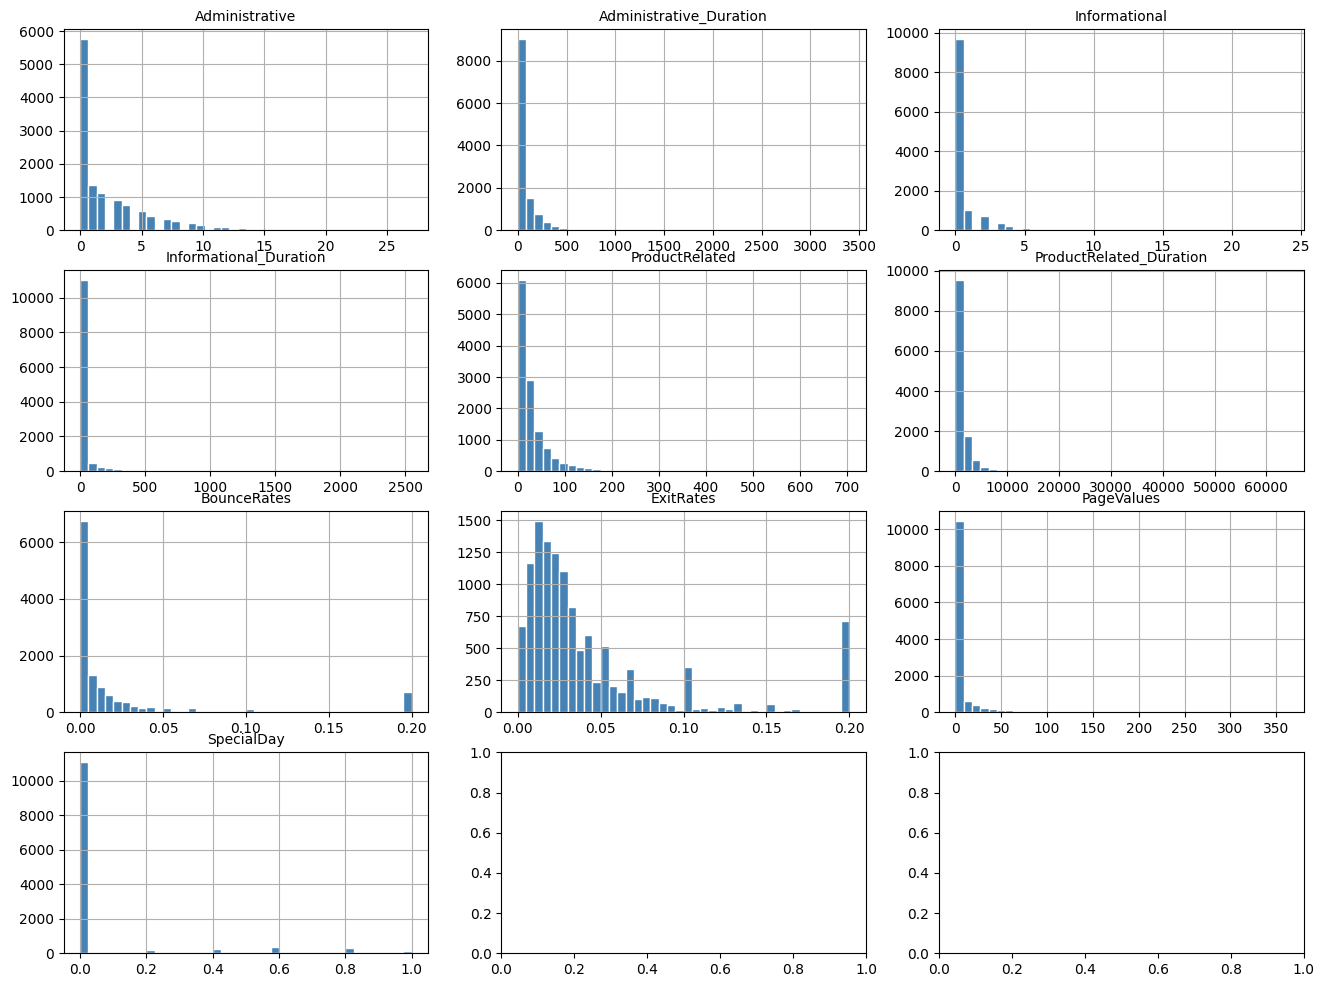

In [55]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 3

fig, axes = plt.subplots(
    n_rows,
    3,
    figsize=(16, n_rows * 3)
)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].hist(
        bins=40,
        ax=axes[i],
        color="steelblue",
        edgecolor="white"
    )
    axes[i].set_title(col, fontsize=10)

Наблюдаются выбросы, причеv очень сильные как например в Product_duration. Надо ли их будет устранять в дальнейшем, пока не понятно

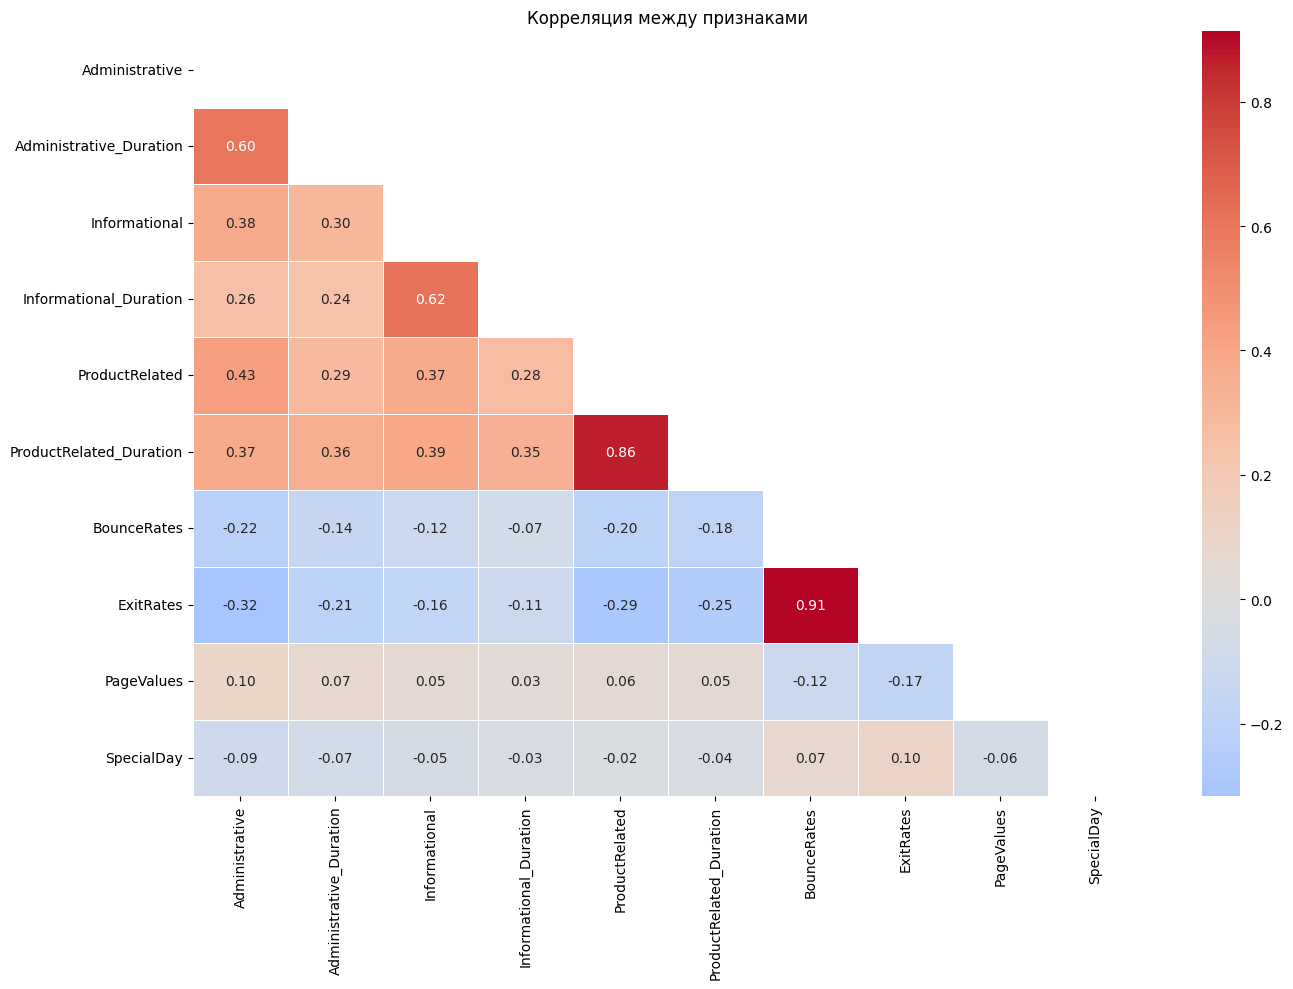

In [56]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Сильная связь наблюдается между признаками связанами с выходом со страницы или же с продолжительностью на ней


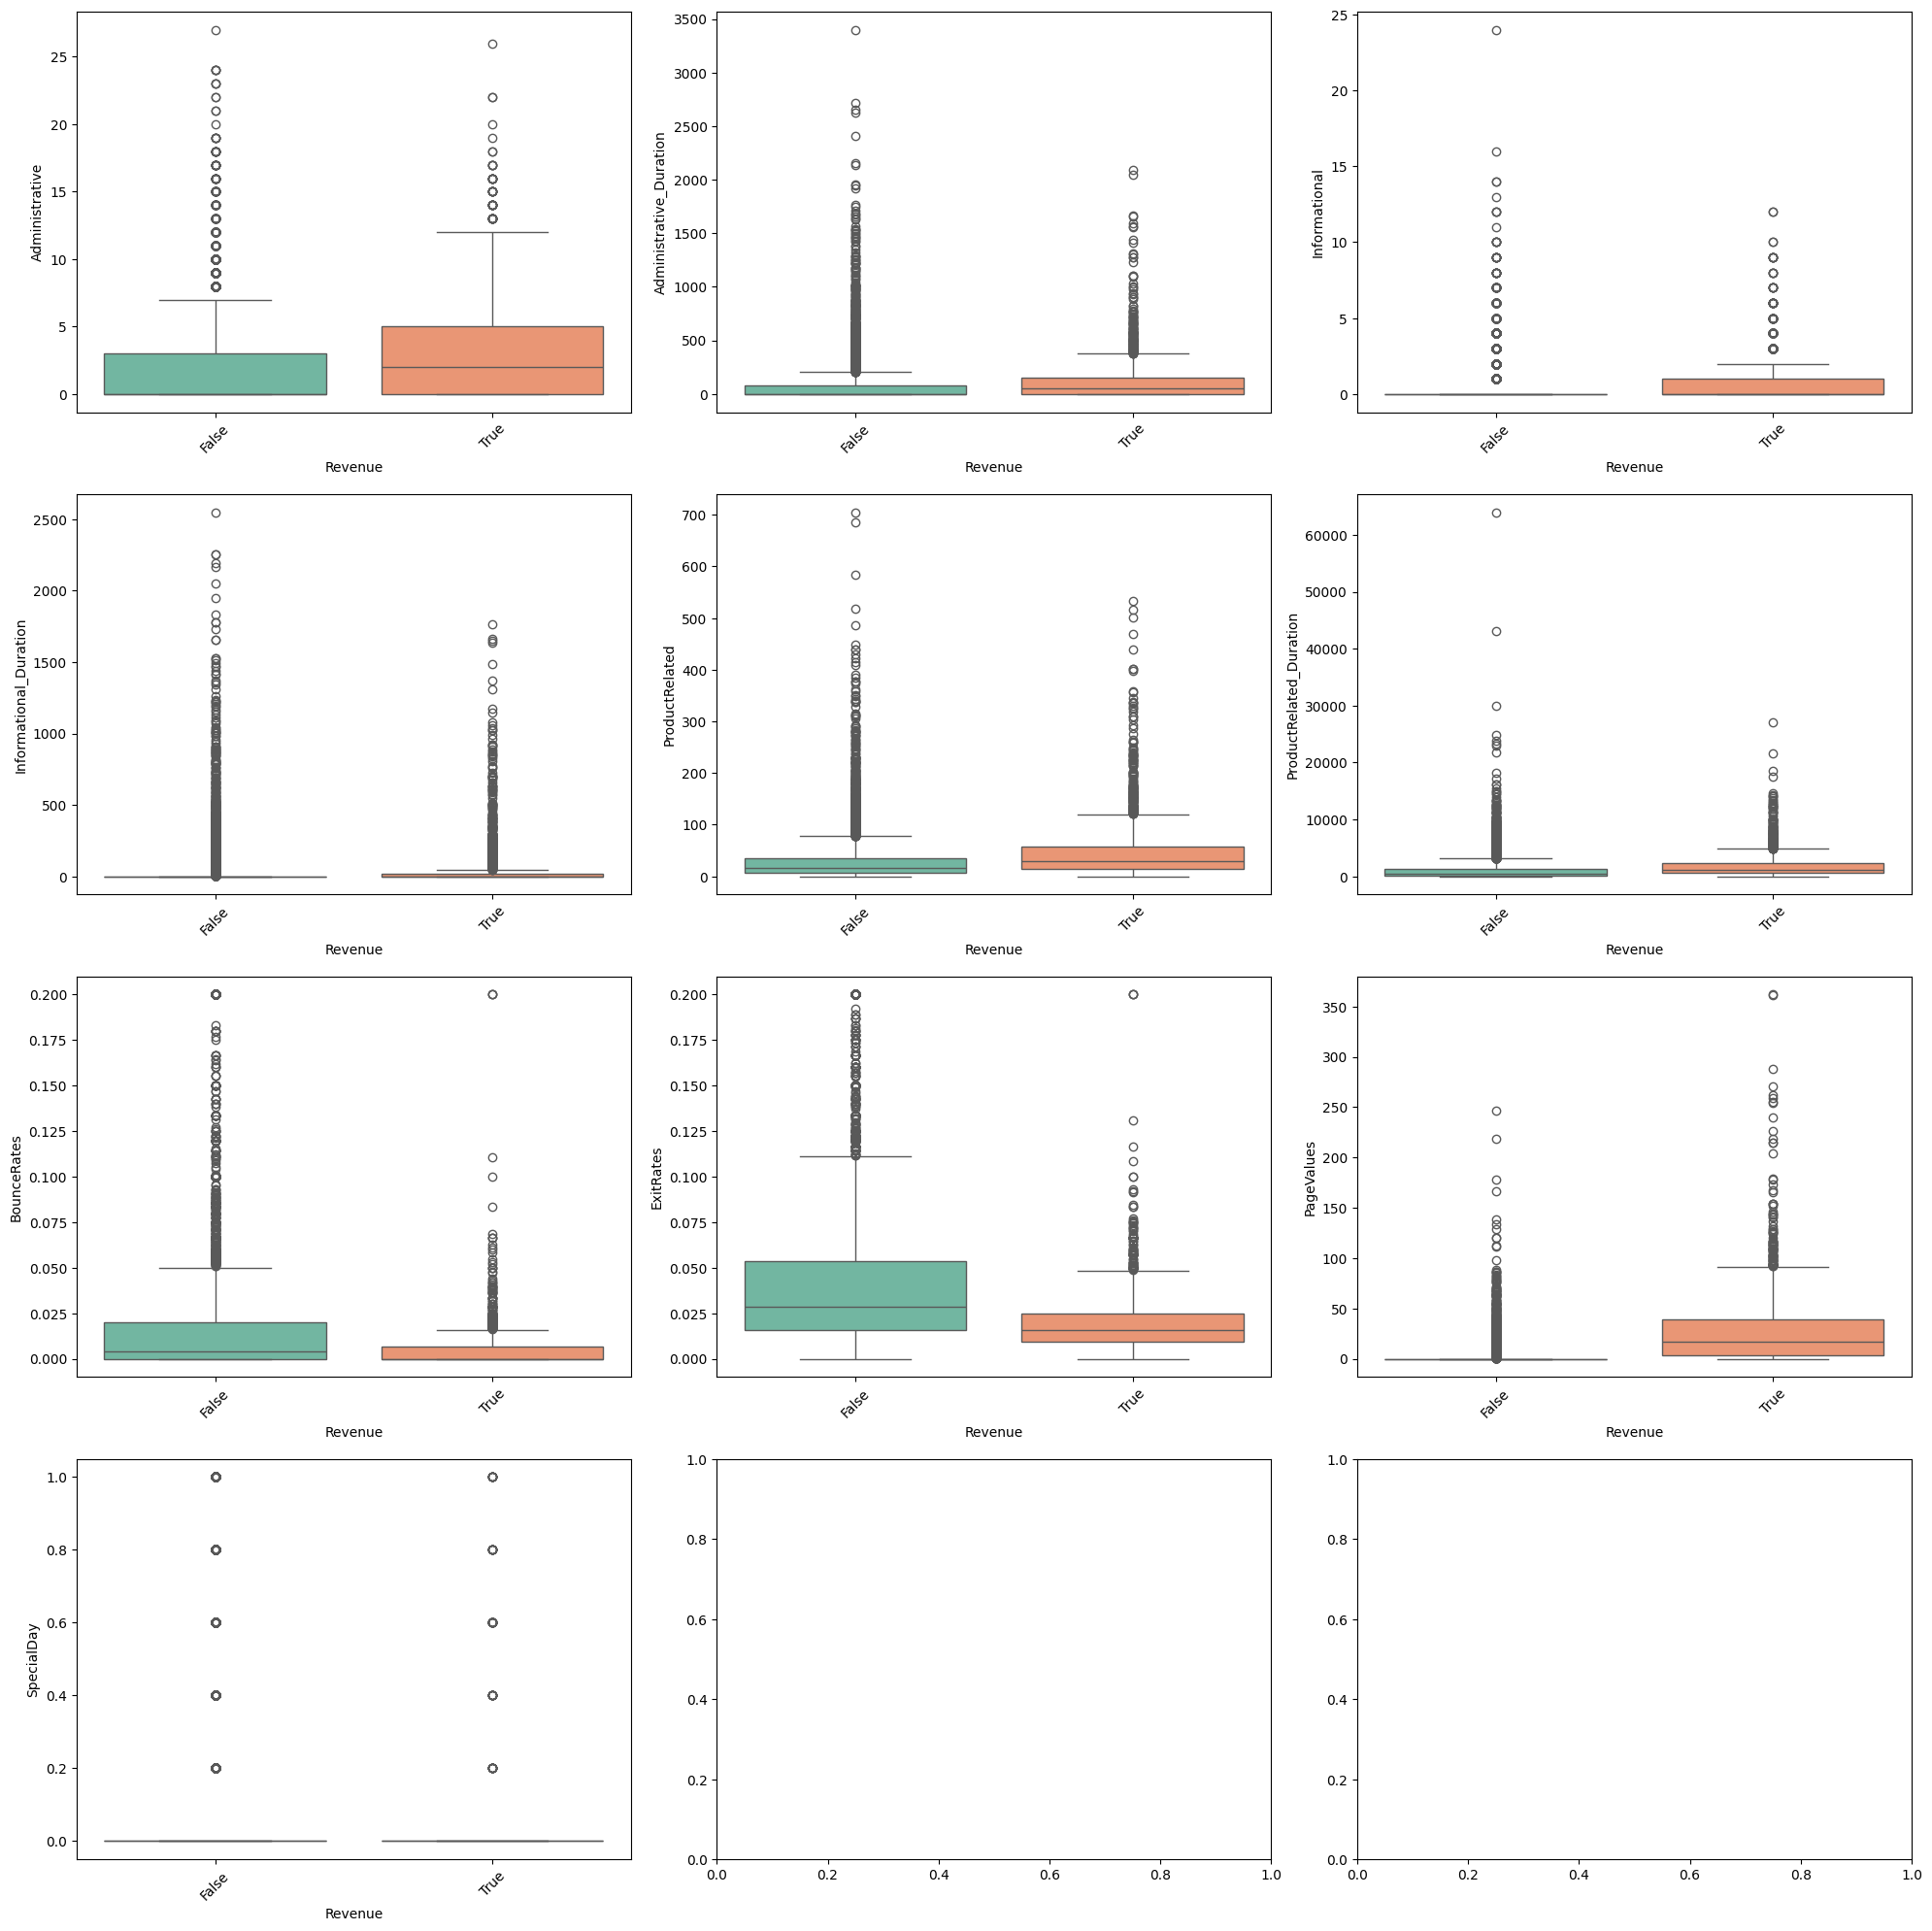

In [57]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(
    data=df,
    x=target,
    y=col,
    hue=target,
    ax=ax,
    palette="Set2",
    legend=False
)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

По этим ящикам с усами видим, что у нас очень много где есть смещение относительно среднего. Причем оно правосторонее. Но этих выбросов везде очень много. Устранять это не будем, так как я считаю, что эти данные все же важны. Сделаю скидку на то, что у нас как минимум есть сезонность покупок. И если мы начнем что то выбрасывать (например большое кол во покупок в какой то месяц), то мы потеряем важную информацию

Теперь разберемся с остальными признаками.

In [58]:
for col in cat_bin_cols:
    print(f"\n")
    print(df[col].value_counts())



Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64


Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64


Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64


TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64


Weekend
False    9462
Tr

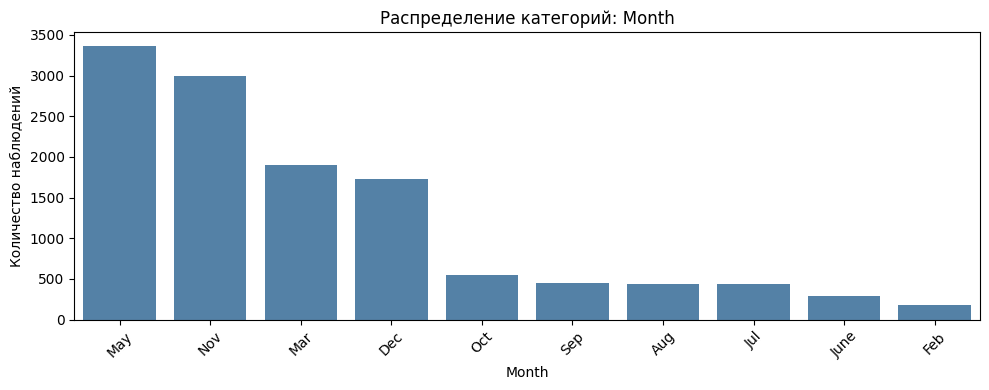

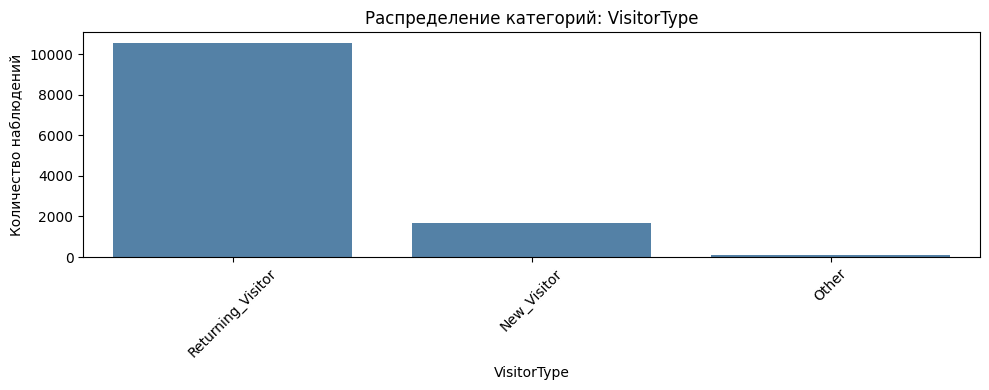

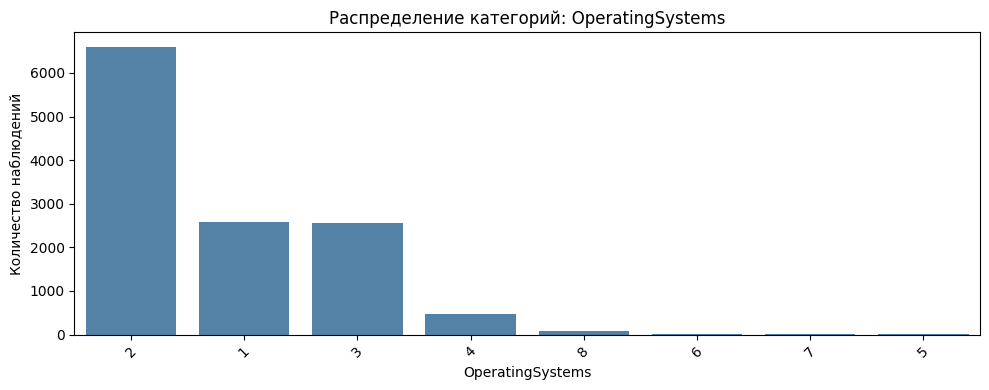

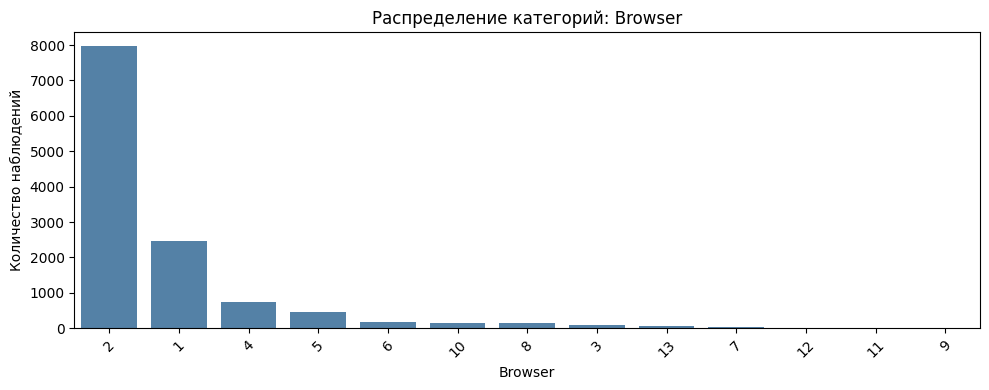

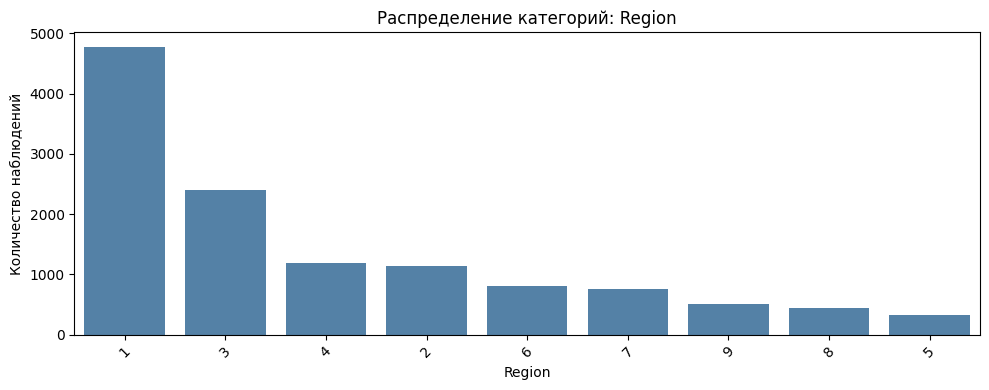

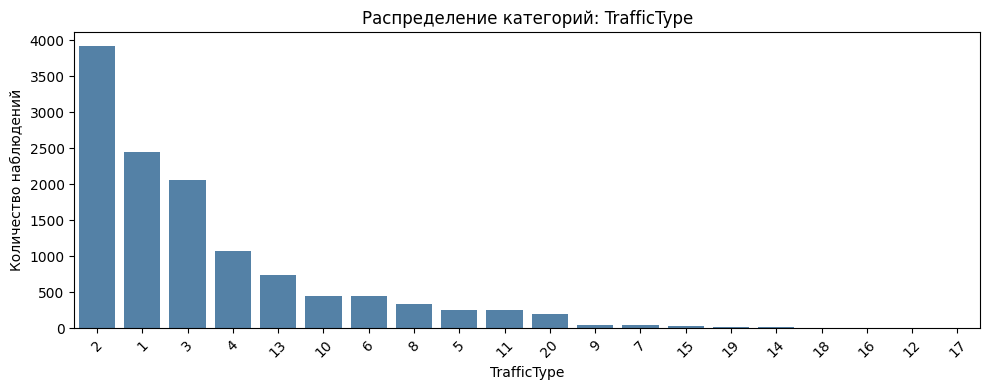

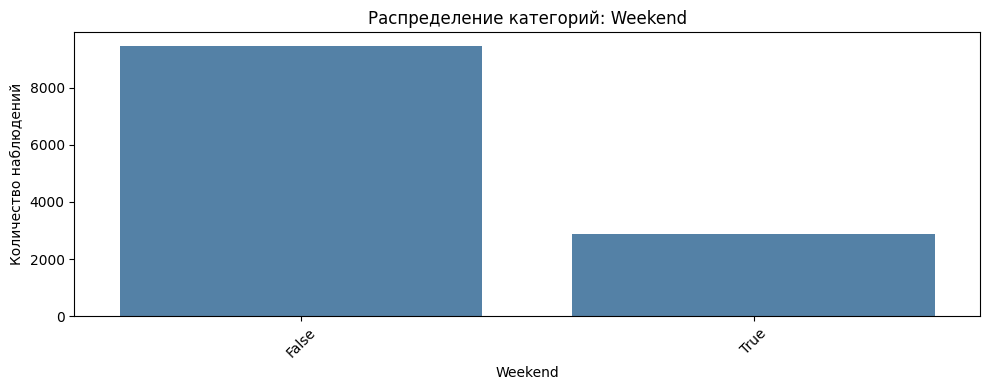

In [59]:
for col in cat_bin_cols:
    plt.figure(figsize=(10, 4))

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        color="steelblue"
    )

    plt.title(f"Распределение категорий: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество наблюдений")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [60]:
for col in cat_bin_cols:
    conversion = pd.crosstab(
        df[col],
        df["Revenue"],
        normalize="index"
    )

    print(f"\nКонверсия по признаку: {col}")
    print(conversion)


Конверсия по признаку: Month
Revenue     False     True 
Month                      
Aug      0.824480  0.175520
Dec      0.874928  0.125072
Feb      0.983696  0.016304
Jul      0.847222  0.152778
June     0.899306  0.100694
Mar      0.899318  0.100682
May      0.891498  0.108502
Nov      0.746498  0.253502
Oct      0.790528  0.209472
Sep      0.808036  0.191964

Конверсия по признаку: VisitorType
Revenue               False     True 
VisitorType                          
New_Visitor        0.750885  0.249115
Other              0.811765  0.188235
Returning_Visitor  0.860677  0.139323

Конверсия по признаку: OperatingSystems
Revenue              False     True 
OperatingSystems                    
1                 0.853385  0.146615
2                 0.825027  0.174973
3                 0.895108  0.104892
4                 0.822176  0.177824
5                 0.833333  0.166667
6                 0.894737  0.105263
7                 0.857143  0.142857
8                 0.784810  0.2151

Доля покупок заметно различается по месяцам. В ферале самая низкая 1.6%, а в ноябре самая выоская около 26% (скорее всего закупки перед крисмас). Новые покупатели покупают чаще, чем вернувшиеся и другие. Это уже подтверждает верность гипотезы 3

Применим one-hot кодирование ко всем катригориальным и бинарным признакам (кроме Revenue). Посмотрим потом, как это отразиться на обучении и в целом на исследовании.

In [61]:
X = df.drop(columns="Revenue").copy()
y = df["Revenue"].astype(int)

X_encoded = pd.get_dummies(
    X,
    columns=cat_bin_cols,
    dtype=int
)

print("Размер до кодирования:", X.shape)
print("Размер после кодирования:", X_encoded.shape)

X_encoded.head()

Размер до кодирования: (12330, 17)
Размер после кодирования: (12330, 75)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,Weekend_False,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


Да, много, но при условии 12к записей это вполне нормально. К тому же не все признаки особо значимы (пока это все еще гипотеза под номером 1)

# 4. Обучение, CV, GridSearch

План такой:
- Сначала выбираем модели и делаем на них обзор
- Собираем пайплайн (туда сразу пихаем и масштабирование) и делаем кросс вадидацию
- Подбор гиперапарметров

## 4.1 Модели
Я в итоге выбрал:
- Logistic Regression с L2
- Logistic Regression с L1
- Logistic Regression с Elastic Net
- Decision Tree
- Random Forest 

Сделаем разлеление на обучающую и тестовую выборку. При дальнейшей кросс валидации разделим выборку еще раз, без предварительной кодировки и скалирования

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

### LogReg L2

In [64]:
from sklearn.linear_model import LogisticRegression

logreg_l2 = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=42
)
logreg_l2.fit(X_train_scaled, y_train)

y_pred_l2 = logreg_l2.predict(X_test_scaled)
y_proba_l2 = logreg_l2.predict_proba(X_test_scaled)[:, 1]

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

print("Accuracy:", accuracy_score(y_test, y_pred_l2))
print("Precision:", precision_score(y_test, y_pred_l2))
print("Recall:", recall_score(y_test, y_pred_l2))
print("F1 macro:", f1_score(y_test, y_pred_l2, average="macro"))
print("ROC AUC:", roc_auc_score(y_test, y_proba_l2))

Accuracy: 0.8807785888077859
Precision: 0.7365591397849462
Recall: 0.3586387434554974
F1 macro: 0.7075124901563368
ROC AUC: 0.8827868275869


### LogReg L1

In [66]:
logreg_l1 = LogisticRegression(
    solver="saga",
    l1_ratio=1,
    max_iter=10000,
    random_state=42
)
logreg_l1.fit(X_train_scaled, y_train)

y_pred_l1 = logreg_l1.predict(X_test_scaled)
y_proba_l1 = logreg_l1.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))
print("Recall:", recall_score(y_test, y_pred_l1))
print("F1 macro:", f1_score(y_test, y_pred_l1, average="macro"))
print("ROC AUC:", roc_auc_score(y_test, y_proba_l1))

Accuracy: 0.8819951338199513
Precision: 0.7433155080213903
Recall: 0.36387434554973824
F1 macro: 0.710939611616618
ROC AUC: 0.8841120579634414


Как нам известно, L1-ругляризация обнуляет веса признаков, которые модель сочла не очень важными. Посмотрим, какие признаки попали под обнуление

In [67]:
coef_table = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": logreg_l1.coef_[0]
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

In [68]:
zero_features = coef_table[
    np.isclose(coef_table["coefficient"], 0, atol=1e-6)
]

print("Количество занулённых признаков:", len(zero_features))
zero_features["feature"].tolist()

Количество занулённых признаков: 20


['VisitorType_Other',
 'VisitorType_Returning_Visitor',
 'OperatingSystems_1',
 'OperatingSystems_5',
 'OperatingSystems_7',
 'OperatingSystems_8',
 'Browser_4',
 'Browser_9',
 'Browser_11',
 'Browser_13',
 'Region_1',
 'TrafficType_7',
 'TrafficType_9',
 'TrafficType_12',
 'TrafficType_14',
 'TrafficType_16',
 'TrafficType_17',
 'TrafficType_18',
 'TrafficType_19',
 'Weekend_True']

Как и ожидалось, много каких признаков после one-hot зануляься, особенно технические характеристики такие как операционка, трафик и браузеры. Это подтверждает гипотезу 1.

### LogReg Elastic Net

In [69]:
logreg_elastic = LogisticRegression(
    solver="saga",
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

logreg_elastic.fit(X_train_scaled, y_train)

y_pred_elastic = logreg_elastic.predict(X_test_scaled)
y_proba_elastic = logreg_elastic.predict_proba(X_test_scaled)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_elastic))
print("Precision:", precision_score(y_test, y_pred_elastic))
print("Recall:", recall_score(y_test, y_pred_elastic))
print("F1 macro:", f1_score(y_test, y_pred_elastic, average="macro"))
print("ROC AUC:", roc_auc_score(y_test, y_proba_elastic))

Accuracy: 0.8811841038118411
Precision: 0.7379679144385026
Recall: 0.3612565445026178
F1 macro: 0.7089529422806496
ROC AUC: 0.8835229271135855


In [70]:
metrics_l2 = {
    "Accuracy": accuracy_score(y_test, y_pred_l2),
    "Precision": precision_score(y_test, y_pred_l2),
    "Recall": recall_score(y_test, y_pred_l2),
    "F1 macro": f1_score(y_test, y_pred_l2, average="macro"),
    "ROC AUC": roc_auc_score(y_test, y_proba_l2)
}

metrics_l1 = {
    "Accuracy": accuracy_score(y_test, y_pred_l1),
    "Precision": precision_score(y_test, y_pred_l1),
    "Recall": recall_score(y_test, y_pred_l1),
    "F1 macro": f1_score(y_test, y_pred_l1, average="macro"),
    "ROC AUC": roc_auc_score(y_test, y_proba_l1)
}

metrics_elastic = {
    "Accuracy": accuracy_score(y_test, y_pred_elastic),
    "Precision": precision_score(y_test, y_pred_elastic),
    "Recall": recall_score(y_test, y_pred_elastic),
    "F1 macro": f1_score(y_test, y_pred_elastic, average="macro"),
    "ROC AUC": roc_auc_score(y_test, y_proba_elastic)
}

In [71]:
results_df = pd.DataFrame(
    [metrics_l2, metrics_l1, metrics_elastic],
    index=[
        "LogReg L2",
        "LogReg L1",
        "LogReg Elastic Net"
    ]
)

results_df.round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
LogReg L2,0.881,0.737,0.359,0.708,0.883
LogReg L1,0.882,0.743,0.364,0.711,0.884
LogReg Elastic Net,0.881,0.738,0.361,0.709,0.884


Пока мы не можем сказать, что есть заметные различия. Но видим, что по всем метрикам лучше всез ЛогРег с Lasso. Это скорее всего связано с тем, что он занулил очень много слабых признаков, которые как раз таки получились при one-hot.

### Decision tree

In [86]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

In [87]:
metrics_tree = {
    "Accuracy": accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall": recall_score(y_test, y_pred_tree),
    "F1 macro": f1_score(
        y_test,
        y_pred_tree,
        average="macro"
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_proba_tree
    )
}

pd.DataFrame(
    [metrics_tree],
    index=["Decision Tree"]
).round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
Decision Tree,0.866,0.569,0.56,0.743,0.741


In [88]:
results_df.loc["Decision Tree"] = metrics_tree

results_df.round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
LogReg L2,0.881,0.737,0.359,0.708,0.883
LogReg L1,0.882,0.743,0.364,0.711,0.884
LogReg Elastic Net,0.881,0.738,0.361,0.709,0.884
Decision Tree,0.866,0.569,0.560,0.743,0.741


Дерево тоже не дало какой то ясности в том, какая модель лучше. F1 макро получился больше, а вот в accuracy и roc auc показатели просели. При этом дерево больше распознало тех, кто по настоящему сделал покупку.

Далее посмотрим, как глубина дерева влияет на качество

In [91]:
depths = [2, 3, 5, 7, 10, 15]

depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_proba = tree.predict_proba(X_train)[:, 1]
    test_proba = tree.predict_proba(X_test)[:, 1]

    depth_results.append({
        "max_depth": depth,
        "train_f1_macro": f1_score(
            y_train,
            train_pred,
            average="macro"
        ),
        "test_f1_macro": f1_score(
            y_test,
            test_pred,
            average="macro"
        ),
        "train_roc_auc": roc_auc_score(
            y_train,
            train_proba
        ),
        "test_roc_auc": roc_auc_score(
            y_test,
            test_proba
        )
    })

depth_results_df = pd.DataFrame(depth_results)
depth_results_df.round(3)

,max_depth,train_f1_macro,test_f1_macro,train_roc_auc,test_roc_auc
0,2,0.758,0.732,0.896,0.893
1,3,0.799,0.790,0.911,0.901
2,5,0.814,0.792,0.930,0.917
3,7,0.842,0.779,0.946,0.894
4,10,0.902,0.759,0.977,0.817
5,15,0.974,0.739,0.998,0.758


Самый хороший результат при глубине 5. Дальше получаем переобучение. На обучающей выборке у нас качество увеличивается, а вот на тестовой наоборот. Это доказывает верность гипотезы 5

### Random Forest

In [92]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]

In [93]:
metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 macro": f1_score(
        y_test,
        y_pred_rf,
        average="macro"
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_proba_rf
    )
}

pd.DataFrame(
    [metrics_rf],
    index=["Random Forest"]
).round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
Random Forest,0.9,0.779,0.497,0.775,0.916


In [94]:
results_df.loc["Random Forest"] = metrics_rf

results_df.round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
LogReg L2,0.881,0.737,0.359,0.708,0.883
LogReg L1,0.882,0.743,0.364,0.711,0.884
LogReg Elastic Net,0.881,0.738,0.361,0.709,0.884
Decision Tree,0.866,0.569,0.560,0.743,0.741
Random Forest,0.900,0.779,0.497,0.775,0.916


В итоге получаем, что алгоритм Random Forest дал наилучший показания среди всех. При этом важно заметить различия именно между одним деревом и ансамблем. Заметное различие наблюдается ROC AUC. Это значит что лес улучшил способность ранжировать и отличать классы.

Посмотрим важность признаков.

In [95]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
8,PageValues,0.324085
7,ExitRates,0.081202
5,ProductRelated_Duration,0.079632
4,ProductRelated,0.069832
1,Administrative_Duration,0.054531
6,BounceRates,0.050626
0,Administrative,0.042573
3,Informational_Duration,0.025671
17,Month_Nov,0.018856
2,Informational,0.018448


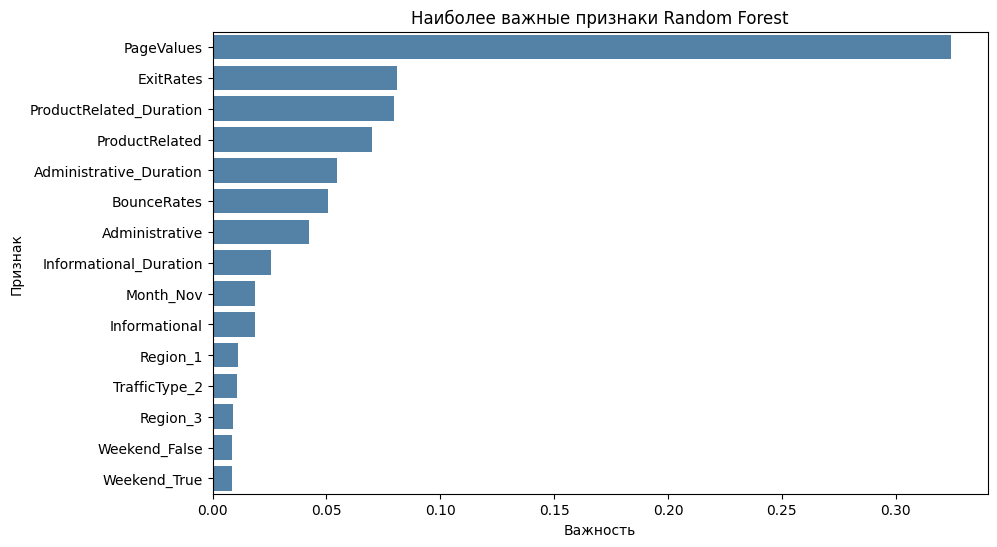

In [96]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature",
    color="steelblue"
)

plt.title("Наиболее важные признаки Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

Признак PageValues - показатель, который информирует о том, насколько покупатель близок к покупке, при этом посетив достатончо ценные страницы. Очевидно, что этот показатель будет самый важный при классификации, он буквально к этому и подводит

Проверим важность через перемешивание признака

In [97]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    random_forest,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [98]:
permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

permutation_importance_df.head(15)

,feature,importance_mean,importance_std
8,PageValues,0.250552,0.007866
17,Month_Nov,0.019268,0.002768
7,ExitRates,0.003854,0.001786
4,ProductRelated,0.003490,0.001708
1,Administrative_Duration,0.003222,0.001871
5,ProductRelated_Duration,0.002904,0.001765
16,Month_May,0.002574,0.000683
0,Administrative,0.002478,0.001704
6,BounceRates,0.002291,0.000817
15,Month_Mar,0.001610,0.000431


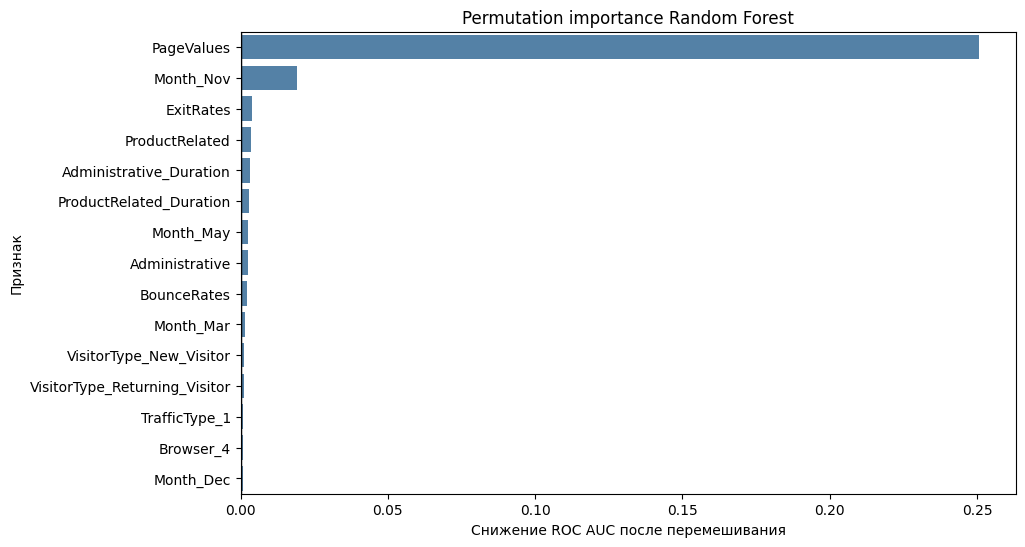

In [99]:
top_features = permutation_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance_mean",
    y="feature",
    color="steelblue"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Permutation importance Random Forest")
plt.xlabel("Снижение ROC AUC после перемешивания")
plt.ylabel("Признак")
plt.show()

importance_mean - насколько в среднем признак падал после перемешивания. И как мы видим, PageValues тоже занимает топ-1. И здесь кстати можно увидеть интересное, что месяц Ноябрь опять вылез на аж топ-2 по важности. Это сто процентов говорит о том, что Ноябрь - сезон покупки подарков. И в это время случается очень много продаж. Это так же вносит вклад в верность гипотезы 3

## Кросс валидация

На предыдущем этапе модели обучались на одном разбиении данных. Теперь сравним их с помощью 5-fold кросс-валидации.

В каждом фолде:
1. данные разделяются на обучающую и валидационную части
2. числовые признаки масштабируются
3. категориальные признаки кодируются через One-Hot Encoding
4. обучение
5. считаются пять метрик качества

Предобработка находится внутри Pipeline. Это позволяет выполнять масштабирование и кодирование отдельно внутри каждого фолда и не использовать информацию из проверочной части при обучении.

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

Разбиваем выборку на тестовую и обучающую

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Делаем предпроцессы. При этом помним что обязательно нужно масштабировать признаки в логрег, но в деревьях этого не нужно делать. Поэтому делаем два предпроцесса.

In [107]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat_bin",
            OneHotEncoder(handle_unknown="ignore"),
            cat_bin_cols
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_cols
        ),
        (
            "cat_bin",
            OneHotEncoder(handle_unknown="ignore"),
            cat_bin_cols
        )
    ]
)

In [114]:
model_specs = {
    "LogReg L2": {
        "preprocessor": linear_preprocessor,
        "model": LogisticRegression(
            solver="lbfgs",
            max_iter=3000,
            random_state=42
        )
    },

    "LogReg L1": {
        "preprocessor": linear_preprocessor,
        "model": LogisticRegression(
            solver="saga",
            l1_ratio=1,
            max_iter=10000,
            random_state=42
        )
    },

    "LogReg Elastic Net": {
        "preprocessor": linear_preprocessor,
        "model": LogisticRegression(
            solver="saga",
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        )
    },

    "Decision Tree": {
        "preprocessor": tree_preprocessor,
        "model": DecisionTreeClassifier(
            random_state=42
        )
    },

    "Random Forest": {
        "preprocessor": tree_preprocessor,
        "model": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    }
}

In [115]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc"
}

In [116]:
results = []

for model_name, spec in model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", spec["preprocessor"]),
            ("model", spec["model"])
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Модель": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 macro": scores["test_f1_macro"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(results)
cv_results.round(3)

,Модель,Accuracy,Precision,Recall,F1 macro,ROC AUC
0,LogReg L2,0.886,0.748,0.393,0.725,0.894
1,LogReg L1,0.885,0.744,0.392,0.724,0.895
2,LogReg Elastic Net,0.885,0.744,0.391,0.723,0.895
3,Decision Tree,0.861,0.552,0.556,0.736,0.737
4,Random Forest,0.901,0.762,0.528,0.784,0.926


Тут мы убеждаемся, что Рэндом форест - лучший выбор. Он сохранил лидерство в среднем по 5 фолдам

## GridSearch

Далее подберем гиперпараметры для Random Forest. После подбора гиперпараметров снова обучем уже на всем X_train и сделаем финальный тест

In [118]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

Зададим сетку параметров. Всего 3 × 4 × 2 × 3 = 72 комбинации

In [123]:
param_grid = {
    "model__n_estimators": [100, 300, 500], # кол-во деревьев в лесу
    "model__max_depth": [5, 10, 15], # макс глубина дерева
    "model__max_features": ["sqrt", "log2"], # сколько признаков использовать при поиске лучшего разбиения
    "model__min_samples_leaf": [1, 2, 5] # минимальное количество объектов в листе
}

Здесь мы будем именно оптимизировать ROC AUC. Именно эта метрика показывает, насколько хорошо мы ранжируем пользователей по вероятности покупки

In [124]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_sco

In [125]:
print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучший средний ROC AUC на кросс-валидации:")
print(round(grid_search.best_score_, 3))

Лучшие параметры:
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 300}

Лучший средний ROC AUC на кросс-валидации:
0.928


Вот мы и получили гиперпараметры, которые показывают лучшие результаты

Теперь проверим полученную модель на тестовой выборке

In [126]:
best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [128]:
grid_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1 macro": f1_score(
        y_test,
        y_pred_best_rf,
        average="macro"
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_proba_best_rf
    )
}

pd.DataFrame(
    [grid_test_metrics],
    index=["Random Forest"]
).round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
Random Forest,0.899,0.782,0.487,0.771,0.919


ROC AUC чуть упало, но это все равно не дает сомнений, что модель мы подобрали хорошую!

# 5. Отбор признаков

До этого мы косвенно затронули тему зануления весов при L1-регуляризации. Теперь попробуем понять что будет, если мы уберем не нужные признаки. Так же попробуем взять топ-20 важных признаков (которые мы проанализировали с помощью feature_importance) и тоже посмотрим на результат

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [145]:
from sklearn.feature_selection import SelectFromModel

In [146]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat_bin",
            OneHotEncoder(handle_unknown="ignore"),
            cat_bin_cols
        )
    ]
)

In [147]:
selector_model = LogisticRegression(
    solver="saga",
    l1_ratio=1,
    max_iter=10000,
    random_state=42
)

logreg_l1_selection_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "selector",
            SelectFromModel(
                estimator=selector_model,
                threshold="median"
            )
        ),
        (
            "model",
            LogisticRegression(
                solver="lbfgs",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

In [148]:
logreg_l1_selection_pipeline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "selector",
            SelectFromModel(
                estimator=selector_model,
                threshold="median"
            )
        ),
        (
            "model",
            LogisticRegression(
                solver="lbfgs",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

In [149]:
selection_scores = cross_validate(
    logreg_l1_selection_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

selection_results = {
    "Модель": "LogReg L1 selection",
    "Accuracy": selection_scores["test_accuracy"].mean(),
    "Precision": selection_scores["test_precision"].mean(),
    "Recall": selection_scores["test_recall"].mean(),
    "F1 macro": selection_scores["test_f1_macro"].mean(),
    "ROC AUC": selection_scores["test_roc_auc"].mean()
}

pd.DataFrame([selection_results]).round(3)

,Модель,Accuracy,Precision,Recall,F1 macro,ROC AUC
0,LogReg L1 selection,0.885,0.748,0.388,0.723,0.894


Вспомним кросс валидацию до этого:
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Модель</th>
      <th>Accuracy</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1 macro</th>
      <th>ROC AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>LogReg L2</td>
      <td>0.886</td>
      <td>0.748</td>
      <td>0.393</td>
      <td>0.725</td>
      <td>0.894</td>
    </tr>
    <tr>
      <th>1</th>
      <td>LogReg L1</td>
      <td>0.885</td>
      <td>0.744</td>
      <td>0.392</td>
      <td>0.724</td>
      <td>0.895</td>
    </tr>
    <tr>
      <th>2</th>
      <td>LogReg Elastic Net</td>
      <td>0.885</td>
      <td>0.744</td>
      <td>0.391</td>
      <td>0.723</td>
      <td>0.895</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Decision Tree</td>
      <td>0.861</td>
      <td>0.552</td>
      <td>0.556</td>
      <td>0.736</td>
      <td>0.737</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Random Forest</td>
      <td>0.901</td>
      <td>0.762</td>
      <td>0.528</td>
      <td>0.784</td>
      <td>0.926</td>
    </tr>
  </tbody>
</table>
</div>

Получаем, что отбор не дал прироста качества, но и практически не ухудшил его. То есть гипотеза 4 не подтвердилась(

Теперь попробуем отобрать топ-20 важных признаков и обучим модель с лучшими гиперпараметрами по Random Forest. Посмотрим что будет..

In [150]:
top20_tuned_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "selector",
            SelectFromModel(
                estimator=RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    n_jobs=-1
                ),
                threshold=-np.inf,
                max_features=20
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                max_features="sqrt",
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [151]:
top20_tuned_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Administrative','Administrative_Duration','Informational',..., 'TrafficType','VisitorType','Weekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [152]:
y_pred_top20 = top20_tuned_pipeline.predict(X_test)
y_proba_top20 = top20_tuned_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
top20_test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_top20
    ),
    "Precision": precision_score(
        y_test,
        y_pred_top20
    ),
    "Recall": recall_score(
        y_test,
        y_pred_top20
    ),
    "F1 macro": f1_score(
        y_test,
        y_pred_top20,
        average="macro"
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        y_proba_top20
    )
}

pd.DataFrame(
    [top20_test_metrics],
    index=["Random Forest + top-20"]
).round(3)

,Accuracy,Precision,Recall,F1 macro,ROC AUC
Random Forest tuned + top-20,0.899,0.731,0.555,0.786,0.921


Что было до отбора:
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Accuracy</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1 macro</th>
      <th>ROC AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Random Forest</th>
      <td>0.899</td>
      <td>0.782</td>
      <td>0.487</td>
      <td>0.771</td>
      <td>0.919</td>
    </tr>
  </tbody>
</table>
</div>

Уменьшение числа признаков до 20 не ухудшило качество. Более того, выросли F1 macro и ROC AUC. Это означает, что большая часть полезной информации содержится в 20 наиболее важных признаках

# Итоги

В итоге мы рассмотрели датасет с действиями пользователей на сайте и попытались предсказать, совершит ли человек покупку.

Сразу было видно, что в данных есть дисбаланс. Пользователей без покупки намного больше, чем пользователей, которые что-то купили. Поэтому смотреть только на Accuracy было бы неправильно, дополнительно мы использовали Precision, Recall, F1 macro и ROC AUC.

По итогам EDA: конверсия отличается в зависимости от месяца и типа пользователя. Также признак `PageValues` оказался самым важным: он показывает ценность посещённых пользователем страниц и сильно помогает предсказывать покупку.

Были протестированы Logistic Regression, Decision Tree и Random Forest. Логистические регрессии с L1, L2 и Elastic Net показали очень похожие результаты. Decision Tree лучше находило покупателей, но хуже работало по ROC AUC и сильнее переобучалось при увеличении глубины.

Лучшей моделью оказался Random Forest. Он показал лучшие результаты на кросс-валидации: ROC AUC = 0.926 и F1 macro = 0.784. Это значит, что ансамбль деревьев лучше справился с задачей, чем одно дерево и логистические модели.

Также был проведён отбор признаков. L1-регуляризация позволила убрать часть признаков без сильного ухудшения качества. После отбора 20 самых важных признаков Random Forest на текущей тестовой выборке показал F1 macro = 0.786 и ROC AUC = 0.921. То есть уменьшение количества признаков не ухудшило результат